In [94]:
# autograd(diferenciación automática) es el corazon de las librebias modernas de deep learning para entrenar redes neuronales, es el mecanismo que permite calcular gradientes de forma automática.
# entrenar redes neuronales implica modificar el valor de los pesos w de los perceptrones que componen dicha red. Estos se conoce como los parametros del modelo(pesos = parametros).
# un perceptron es una unidad de procesamiento que toma varias entradas, las multiplica por pesos, las suma y luego aplica una funcion de activacion para producir una salida. 
# En el contexto de las redes neuronales, los pesos son los parametros que se ajustan durante el proceso de entrenamiento para minimizar la diferencia entre las predicciones del modelo y 
# los valores reales. 
# Los valores reales se conocen como etiquetas o targets, indican el valor correcto que el modelo debe producir. Por ejemplo, si le mostramos al modelo una foto de un golden retriever, la 
# etiqueta sería "perro". Si el modelo predice "gato", se calcula una funcion de pérdida (loss) alta; si predice "perro", la pérdida es baja o nula. 
# El proceso de entrenamiento consiste en repetir este ciclo miles de veces: el modelo hace una predicción, se mide cuán lejos estuvo de la etiqueta real mediante la función de pérdida, y 
# luego se ajustan los pesos (a través de backpropagation) para que la próxima vez el modelo se equivoque menos.
# La red neuronal no "ve" ni "interpreta" la imagen en el sentido humano. Lo que hace es:
# Recibir la imagen como un array de números (los valores de los píxeles)
# Aplicar una serie de operaciones matemáticas con sus pesos
# Producir una distribución de probabilidades sobre las posibles clases
# Por ejemplo, su salida real podría ser algo así:
# Clases Probabilidad
# perro  0.82
# gato   0.11
# pájaro 0.07
# El modelo no sabe con certeza qué hay en la imagen, solo dice: "dado lo que vi, estimo que hay un 82% de chances de que sea un perro". Eso es una predicción, no una interpretación.
# Se usa el término "predice" precisamente para dejar en claro que:
# El modelo puede equivocarse
# Trabaja con probabilidades, no con certezas
# No hay comprensión real detrás, solo cálculo matemático
# En cambio, decir que "interpreta" implicaría un nivel de comprensión semántica que el modelo no tiene. La palabra "predice" es más honesta sobre lo que realmente ocurre.
# El autograd permite representar la funcion L(loss) como un grafo de operaciones(grafo dirigido aciclico) donde cada nodo, dependiendo su framework, pueden ser: tensores y 
# las aristas operaciones o nodos que representan operaciones y las aristas el flujo de datos entre ellas. Esto permite recorrer el grafo en sentido inverso aplicando la regla
# de la cadena en cada paso, lo que es exactamente el algoritmo de backpropagation. De esta manera, se  calculan las derivadas respecto a cada peso sin tener que derivar la 
# función completa a mano.
# El autograd calcula el gradiente de los nodos intermedios mediante el calculo de las derivadas parciales(backpropagation) de cada nodo con respecto al nodo raiz, L. Este gradiente
# indica que pasa con L si el valor del nodo aumenta o disminuye.

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [95]:
def f(x):
    return 2*x**2 - 3*x + 4

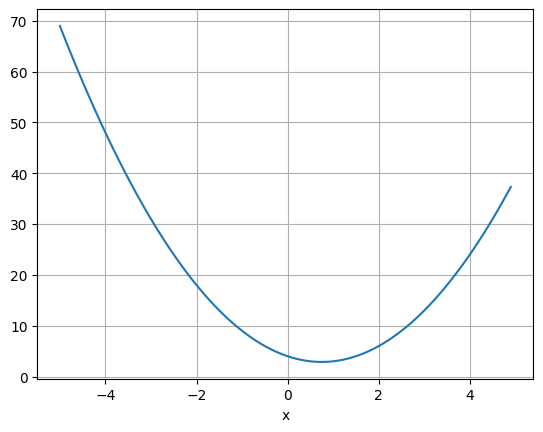

In [96]:
xs = np.arange(-5, 5, 0.1)
plt.plot(xs,f(xs))
plt.xlabel('x')
plt.grid()

In [97]:
h = 0.0000000000000001
x = 0
(f(x+h) - f(x)) / h

-4.440892098500626

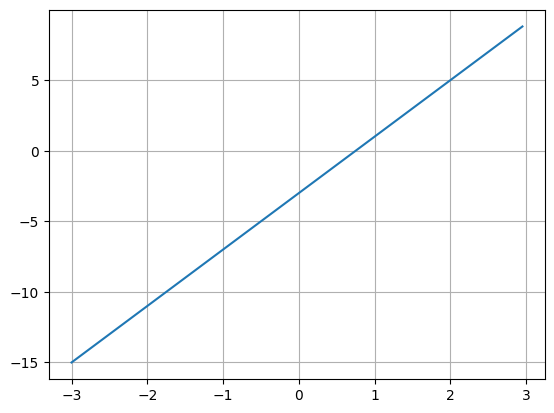

In [98]:
xs = np.arange(-3, 3, 0.05)
h = 0.00001
plt.plot(xs, (f(xs+h) - f(xs)) / h)
plt.grid()

In [99]:
x = 2 #variable (dato fijo)
W = 2 #variable de entrada (peso/parametro del modelo, dato a modificar para minimizar la funcion de perdida)
b = 1 #variable de entrada (peso/parametro del modelo, dato a modificar para minimizar la funcion de perdida)

y = 2 #etiquetas (valores de reales que el modelo intenta predecir, dato fijo)
L = (y - (x * W + b)) ** 2 #(y - y^)^2 (L representa la funcion de perdida. Y^ es la prediccion del modelo)
print(f'L = {L}')

L = 9


Text(0.5, 0, 'W')

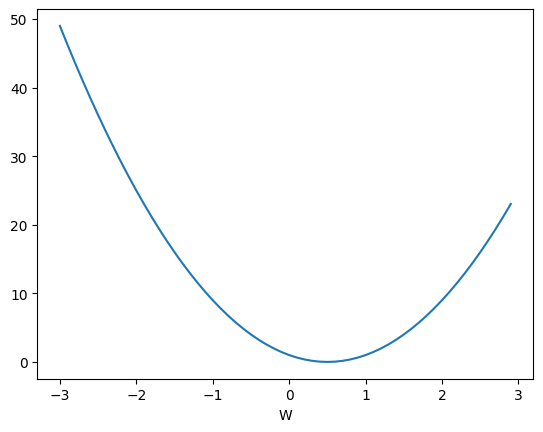

In [100]:
Ws = np.arange(-3, 3, 0.1)
bs = np.arange(-3, 3, 0.1)
plt.plot(Ws, (y - (x * Ws + b)) ** 2)
plt.xlabel('W')

In [101]:
x = 2
W = 0
b = 1

y = 2
L = (y - (x * W + b)) ** 2
dLdW = (((y - (x * W+h + b)) ** 2) - ((y - (x * W + b)) ** 2)) / h
print(f'L = {L}')
print(f'dL/dW = {dLdW}')

L = 1
dL/dW = -1.9999900000122748


Text(0.5, 0, 'b')

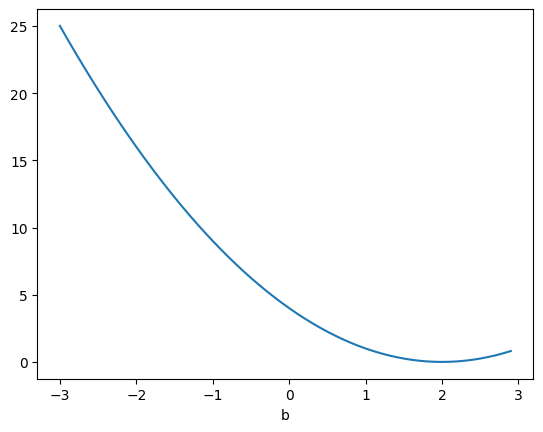

In [102]:
Ws = np.arange(-3, 3, 0.1)
bs = np.arange(-3, 3, 0.1)
plt.plot(Ws, (y - (x * W + bs)) ** 2)
plt.xlabel('b')

In [103]:
x = 2
W = 2
b = 0

y = 2
L = (y - (x * W + b)) ** 2
dLdb = (((y - (x * W + b+h)) ** 2) - ((y - (x * W + b)) ** 2)) / h
print(f'L = {L}')
print(f'dL/db = {dLdb}')

L = 4
dL/db = 4.0000099998493965


In [104]:
Value(4) * Value(5), 5 * Value(4), Value(4) * 5


(Value(data=20, grad=0.0, _children={Value(data=5, grad=0.0, _children=set(), _op=""), Value(data=4, grad=0.0, _children=set(), _op="")}, _op="*"),
 Value(data=20, grad=0.0, _children={Value(data=4, grad=0.0, _children=set(), _op=""), Value(data=5, grad=0.0, _children=set(), _op="")}, _op="*"),
 Value(data=20, grad=0.0, _children={Value(data=4, grad=0.0, _children=set(), _op=""), Value(data=5, grad=0.0, _children=set(), _op="")}, _op="*"))

In [105]:
Value(5) * Value(3) - Value(2)

Value(data=13, grad=0.0, _children={Value(data=15, grad=0.0, _children={Value(data=5, grad=0.0, _children=set(), _op=""), Value(data=3, grad=0.0, _children=set(), _op="")}, _op="*"), Value(data=-2, grad=0.0, _children={Value(data=-1, grad=0.0, _children=set(), _op=""), Value(data=2, grad=0.0, _children=set(), _op="")}, _op="*")}, _op="+")

In [106]:
Value(5) + Value(2)

Value(data=7, grad=0.0, _children={Value(data=5, grad=0.0, _children=set(), _op=""), Value(data=2, grad=0.0, _children=set(), _op="")}, _op="+")

In [107]:
5 - Value(3)

Value(data=2, grad=0.0, _children={Value(data=-3, grad=0.0, _children={Value(data=3, grad=0.0, _children=set(), _op=""), Value(data=-1, grad=0.0, _children=set(), _op="")}, _op="*"), Value(data=5, grad=0.0, _children=set(), _op="")}, _op="+")

In [108]:
Value(5) * Value(2)

Value(data=10, grad=0.0, _children={Value(data=2, grad=0.0, _children=set(), _op=""), Value(data=5, grad=0.0, _children=set(), _op="")}, _op="*")

In [109]:
W0 = Value(5, name='W0')
x0 = Value(.5, name='x0')
W1 = Value(3, name='W1')
x1 = Value(-2, name='x1')
W0x0 = W0 * x0
W1x1 = W1 * x1
W0x0.name = 'W0x0'
W1x1.name = 'W1x1'
out = W0x0 + W1x1 
out.name = 'out'
out

Value(data=-3.5, grad=0.0, _children={Value(data=-6, grad=0.0, _children={Value(data=3, grad=0.0, _children=set(), _op=""), Value(data=-2, grad=0.0, _children=set(), _op="")}, _op="*"), Value(data=2.5, grad=0.0, _children={Value(data=5, grad=0.0, _children=set(), _op=""), Value(data=0.5, grad=0.0, _children=set(), _op="")}, _op="*")}, _op="+")

In [110]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def show_graph(root, format='svg', rankdir='LR'):
    assert rankdir in ['LR', 'TB']
    nodes, edges= trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    for n in nodes:
        dot.node(name=str(id(n)), label="{%s | data %.4f | grad %.4f }" % (n.name, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


In [111]:
import os
os.environ['PATH'] += r';C:\Program Files\Graphviz\bin'

In [112]:
#Parte 2 - La clase Value

class Value():
    def __init__(self, data, _children=(), _op='', name=''):
        self.data = data
        self._op = _op
        self.grad = 0.0
        self._prev = set(_children)
        self.name = name

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __repr__(self):
        return f'Value(data={self.data}, grad={self.grad}, _children={self._prev}, _op="{self._op}")'

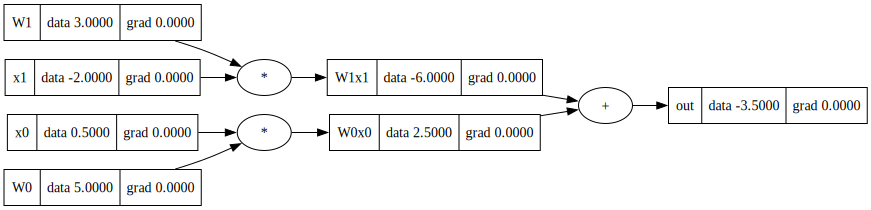

In [113]:
show_graph(out)

In [117]:
#Parte 3 - Haciendo Backpropagation a mano para una neurona

a = Value(-2., name= 'a')
b = Value(3., name= 'b')
c = Value(.5, name= 'c')
ab = a * b; ab.name = 'ab'
d = ab + c; d.name = 'd'
e = Value(-.5, name='e')
f = d * e; f.name = 'f'


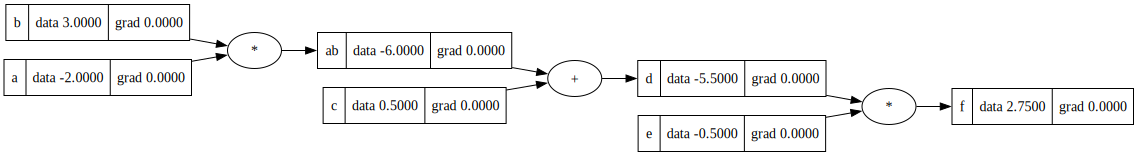

In [115]:
show_graph(f)

In [116]:
df/df
(f + h - f) /h = h/h = 1

df/de
f = e * d
((e + h) * d) - (e * d) / h = (e * d + h * d - e * d) / h = h * d / h = d

df/dd
f = e * d
(e * (d + h)) - (e * d) / h = (e * d + e * h - e * d) / h = e * h / h = e

#regla de la cadena

df/dc = df/dd * dd/dc
d = c * ab
(((c+h) + ab) - (c + ab )) / h = (c +h + ab - c - ab) / h = 1

df/da = df/dab * dab/da
      = -0.5 * 3
ab = a * b
(((a + h) * b) - (a * b))/ h
(a * b) + b * h - (a * b) / h = b

df/db = df/dab * dab/db
      = -0.5 * -2




SyntaxError: cannot assign to expression (1864406435.py, line 2)

In [118]:
f.grad = 1.
e.grad = d.data
d.grad = e.data
c.grad = d.grad
ab.grad = d.grad
a.grad = ab.grad * b.data
b.grad = ab.grad * a.data


In [119]:
def fun():
    h = 0.0001
    a = Value(-2., name= 'a')
    b = Value(3., name= 'b')
    c = Value(.5, name= 'c')
    ab = a * b; ab.name = 'ab'
    d = ab + c; d.name = 'd'
    e = Value(-.5, name='e')
    f = d * e; f.name = 'f'
    f1 = f.data

    a = Value(-2., name= 'a')
    a += h
    b = Value(3., name= 'b')
    c = Value(.5, name= 'c')
    ab = a * b; ab.name = 'ab'
    d = ab + c; d.name = 'd'
    e = Value(-.5, name='e')
    f = d * e; f.name = 'f'
    f2 = f.data
    print((f2 - f1) / h)
fun()
    


-1.500000000000945


In [120]:
#perceptron, no tiene funcion de activacion, no tiene bias
W0 = Value(-.5, name='W0') #pesos
x0 = Value(.5, name='x0')
W1 = Value(-.3, name='W1')
x1 = Value(2, name='x1')
W0x0 = W0 * x0; W0x0.name = 'W0x0'
W1x1 = W1 * x1; W1x1.name = 'W1x1'
yhat = W0x0 + W1x1; yhat.name = 'yhat' #valor predicho de la funcion
y = Value(.8, name='y') # valor esperado
L = y - yhat; L.name = 'L' #fucion de perdida, diferencia entre el valor real y el predicho

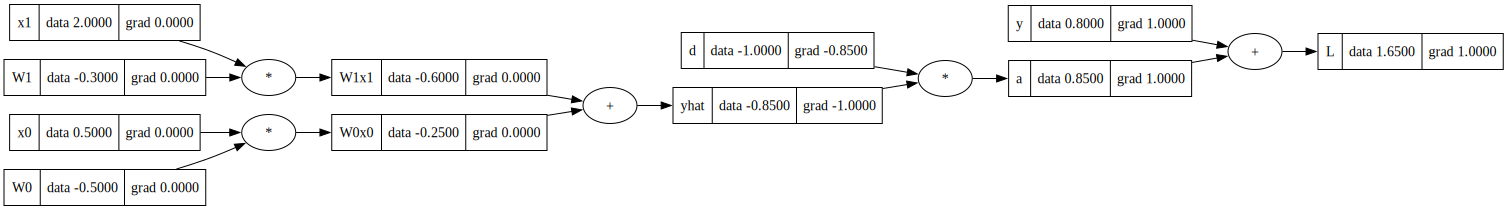

In [125]:
show_graph(L)

In [ ]:
L.grad = 1.
a, b = L._prev
a.name = 'a'  
b.name = 'y'
a.grad = L.grad #el + propaga el gradiente a sus nodos hijos, por lo que el gradiente de a y b es el mismo que el de L
b.grad = L.grad
c, d = a._prev
c.name = 'yhat'
d.name = 'd'
c.grad = a.grad * d.data
d.grad = a.grad * c.data
W0x0.grad = c.grad
W1x1.grad = c.grad
W0.grad = W0x0.grad * x0.data
x0.grad = W0x0.grad * W0.data
W1.grad = W1x1.grad * x1.data
x1.grad = W1x1.grad * W1.data

In [128]:
def fun2():
    h = 0.0001 #h representa un pequeño cambio en el valor de los pesos, se utiliza para calcular la derivada de la funcion de perdida 
    W0 = Value(-.5, name='W0') #pesos
    x0 = Value(.5, name='x0')
    W1 = Value(-.3, name='W1')
    x1 = Value(2, name='x1')
    W0x0 = W0 * x0; W0x0.name = 'W0x0'
    W1x1 = W1 * x1; W1x1.name = 'W1x1'
    yhat = W0x0 + W1x1; yhat.name = 'yhat' #valor predicho de la funcion
    y = Value(.8, name='y') # valor esperado
    L = y - yhat; L.name = 'L' #fucion de perdida, diferencia entre el valor real y el predicho
    L1 = L.data

    W0 = Value(-.5, name='W0') #pesos
    x0 = Value(.5, name='x0')
    W1 = Value(-.3, name='W1')
    x1 = Value(2, name='x1')
    W0x0 = W0 * x0; W0x0.name = 'W0x0'
    W1x1 = W1 * x1; W1x1.name = 'W1x1'
    yhat = W0x0 + W1x1; yhat.name = 'yhat' #valor predicho de la funcion
    y = Value(.8, name='y') # valor esperado
    yhat += h
    L = y - yhat; L.name = 'L' #fucion de perdida, diferencia entre el valor real y el predicho
    L2 = L.data
    print((L2 - L1) / h)
fun2()

-0.9999999999976694
